In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q diffusers transformers accelerate safetensors huggingface_hub gradio

In [3]:
from huggingface_hub import notebook_login

notebook_login()

In [4]:
from huggingface_hub import whoami

print(whoami())

{'type': 'user', 'id': '69cbb2d263c0c61a93ba0da0', 'name': 'rk123iot', 'fullname': 'Pratheeksha', 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1788220800, 'isPro': False, 'avatarUrl': '/avatars/e99fd34589057479c00fd5a6d877e96f.svg', 'orgs': [], 'auth': {'type': 'oauth', 'expiresAt': '2026-09-16T01:09:17.000Z'}}


In [5]:
from diffusers import StableDiffusionPipeline
import torch
import gradio as gr
from PIL import Image

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [6]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

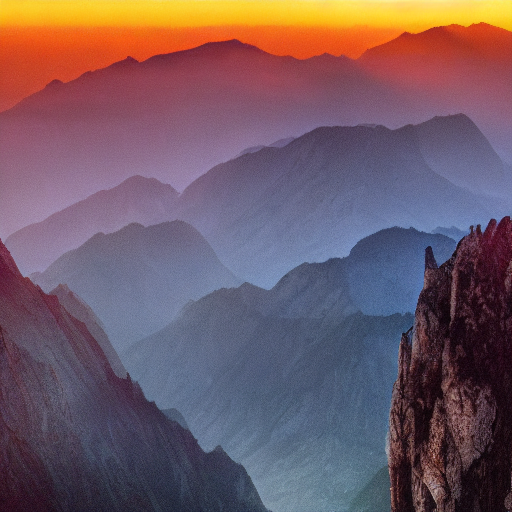

In [7]:
prompt = "A beautiful sunset over the mountains, cinematic lighting, highly detailed"

image = pipe(prompt).images[0]

image

In [8]:
def generate_image(prompt):
    image = pipe(prompt).images[0]
    return image

  0%|          | 0/50 [00:00<?, ?it/s]

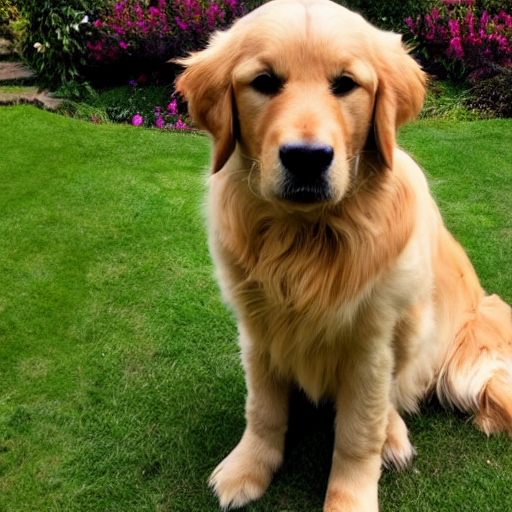

In [9]:
generate_image("A cute golden retriever sitting in a garden")

In [10]:
import gradio as gr

interface = gr.Interface(
    fn=generate_image,
    inputs=gr.Textbox(
        label="Enter your prompt",
        placeholder="Describe the image you want..."
    ),
    outputs=gr.Image(label="Generated Image"),
    title="AI Text-to-Image Generator",
    description="Generate images from natural language prompts using Stable Diffusion."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b34c2196efefe7752b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
import gradio as gr

def generate_image(prompt):
    image = pipe(prompt).images[0]
    return image

interface = gr.Interface(
    fn=generate_image,
    inputs=gr.Textbox(
        label="Enter your prompt",
        placeholder="Describe the image you want..."
    ),
    outputs=gr.Image(label="Generated Image"),
    title="AI Text-to-Image Generator",
    description="Generate images from text using Stable Diffusion"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5399d082833852866a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
